# Prediksi hs-CRP Tinggi (≥3 mg/L) pada Dewasa Indonesia dengan *Explainable Machine Learning* — IFLS-5

Notebook ini mengikuti bagian **Methods** di dokumen IMRaD:

1. Memuat data `crp_ifls5_model.csv` (5.980 responden, 904 CRP tinggi).
2. Menyusun Tabel 1 (deskriptif, uji chi-square, Cramér's V) dan regresi logistik multivariabel (OR terkoreksi, IK 95%, VIF).
3. Membagi data 80/20 terstratifikasi.
4. Melatih 4 model ML (Logistic Regression, Random Forest, XGBoost, LightGBM) + *deep learning* (MLP; DNN PyTorch bila terpasang) + *ensemble*, dengan *tuning* 5-fold CV dan bobot kelas.
5. Mengevaluasi model: AUC-ROC (IK 95% *bootstrap*), AUC-PR, akurasi, akurasi seimbang, sensitivitas, spesifisitas, F1, Brier, serta pilihan ambang untuk menaikkan sensitivitas.
6. Menafsirkan model dengan SHAP: *summary*, *dependence*, dan model per jenis kelamin.
7. Analisis sensitivitas: SMOTE, lingkar pinggang (umur ≥40), dan bobot sampel DBS.

**Cara menjalankan:**
- Taruh notebook ini satu folder dengan `crp_ifls5_model.csv`.
- Jalankan sel instalasi sekali saja, lalu *Run All*.

**Mode pratinjau:** jika XGBoost/LightGBM/SHAP belum terpasang, notebook tetap berjalan dengan pengganti dari scikit-learn. LightGBM diganti `HistGradientBoosting`, XGBoost dilewati, dan SHAP diganti *permutation importance*. Output yang tersimpan di file ini dibuat dalam mode pratinjau. Jalankan ulang setelah instalasi untuk hasil final.

In [1]:
# Jalankan SEKALI di laptop Anda (hapus tanda # di depan baris berikut):
# %pip install torch xgboost lightgbm shap imbalanced-learn scikit-learn pandas matplotlib openpyxl

In [2]:
# === DIAGNOSIS: Python mana yang dipakai Jupyter & kenapa paket gagal ===
import sys, importlib
print("Python yang dipakai notebook:", sys.executable)

for m in ["lightgbm", "shap", "numba", "numpy", "xgboost", "sklearn"]:
    try:
        mod = importlib.import_module(m)
        print(f"OK     {m:10s} versi {getattr(mod, '__version__', '?')}")
    except Exception as e:
        print(f"GAGAL  {m:10s} -> {type(e).__name__}: {str(e)[:200]}")

Python yang dipakai notebook: D:\anaconda3\envs\tesis-env\python.exe
OK     lightgbm   versi 4.7.0


D:\anaconda3\envs\tesis-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OK     shap       versi 0.46.0
OK     numba      versi 0.60.0
OK     numpy      versi 1.26.4
OK     xgboost    versi 2.1.4
OK     sklearn    versi 1.9.1


In [3]:
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score, average_precision_score, f1_score, brier_score_loss,
                             confusion_matrix, roc_curve)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.base import clone

def ada(m):
    try: __import__(m); return True
    except ImportError: return False
HAS_XGB, HAS_LGBM, HAS_SHAP, HAS_IMB = ada('xgboost'), ada('lightgbm'), ada('shap'), ada('imblearn')
MODE = 'FINAL' if (HAS_XGB and HAS_LGBM and HAS_SHAP) else 'PRATINJAU'
print(f'XGBoost={HAS_XGB} | LightGBM={HAS_LGBM} | SHAP={HAS_SHAP} | imbalanced-learn={HAS_IMB}')
print('MODE:', MODE)
SEED = 42
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

XGBoost=True | LightGBM=True | SHAP=True | imbalanced-learn=True
MODE: FINAL


## 1. Memuat data

In [4]:
# === SEL 0: semua hasil disimpan ke folder kerja ===
import os

ROOT = r"F:\SINTA 3\crp-ifls5-ml"            # folder kerja repositori
OUTDIR = os.path.join(ROOT, "results")        # tempat semua hasil (xlsx, png)
os.makedirs(OUTDIR, exist_ok=True)
os.chdir(OUTDIR)                              # semua file yang disimpan notebook masuk ke sini

# pastikan data bisa ditemukan dari folder results
DATA_FILE = os.path.join(ROOT, "data", "crp_ifls5_model.csv")
assert os.path.exists(DATA_FILE), f"Data tidak ditemukan: {DATA_FILE}"
print("Folder kerja :", os.getcwd())
print("File data    :", DATA_FILE)

Folder kerja : F:\SINTA 3\crp-ifls5-ml\results
File data    : F:\SINTA 3\crp-ifls5-ml\data\crp_ifls5_model.csv


In [5]:
import os
#DATA_PATH = next((p for p in ['crp_ifls5_model.csv', '../data/crp_ifls5_model.csv', 'data/crp_ifls5_model.csv'] if os.path.exists(p)), 'crp_ifls5_model.csv')
DATA_PATH = r"F:\SINTA 3\crp-ifls5-ml\data\crp_ifls5_model.csv"
df = pd.read_csv(DATA_PATH)
print('Ukuran data:', df.shape)
print(f"CRP tinggi (>=3 mg/L): {df.crp_high.sum()} dari {len(df)} ({df.crp_high.mean()*100:.1f}%)")
print(f"Median hs-CRP: {df.crp_plas_equi.median():.2f} mg/L | Umur: {df.age.mean():.1f} ± {df.age.std():.1f} th | Perempuan: {df.female.mean()*100:.1f}%")

Ukuran data: (5980, 43)
CRP tinggi (>=3 mg/L): 904 dari 5980 (15.1%)
Median hs-CRP: 0.69 mg/L | Umur: 41.8 ± 17.6 th | Perempuan: 54.1%


## 2. Tabel 1 — Proporsi CRP tinggi menurut karakteristik

In [6]:
grp = {
 'IMT (kg/m²)': pd.cut(df.bmi, [0, 18.5, 23, 25, 30, 99], right=False, labels=['<18,5', '18,5–22,9', '23–24,9', '25–29,9', '≥30']),
 'Jenis kelamin': df.female.map({0: 'Laki-laki', 1: 'Perempuan'}),
 'Umur (tahun)': pd.cut(df.age, [14, 29, 39, 49, 59, 120], labels=['15–29', '30–39', '40–49', '50–59', '≥60']),
 'Status merokok': df.smoke_status.map({0: 'Tidak pernah', 1: 'Mantan', 2: 'Aktif'}),
 'Tempat tinggal': df.urban.map({0: 'Perdesaan', 1: 'Perkotaan'}),
 'Kuintil pengeluaran': df.pce_quintile.astype(int),
 'Pendidikan': df.educ.map({0: 'Tidak sekolah', 1: 'SD', 2: 'SMP', 3: 'SMA', 4: 'Perguruan tinggi'}),
 'Jumlah penyakit kronis': df.n_chronic.clip(upper=2).map({0: '0', 1: '1', 2: '≥2'}),
}
rows = []
for k, g in grp.items():
    t = df.groupby(g, observed=True).crp_high.agg(['size', 'mean'])
    for cat, r in t.iterrows():
        rows.append({'Karakteristik': k, 'Kategori': cat, 'n': int(r['size']), 'CRP tinggi (%)': round(r['mean'] * 100, 1)})
tabel1 = pd.DataFrame(rows)
from scipy.stats import chi2_contingency
uji = []
for k, g in grp.items():
    ct = pd.crosstab(g, df.crp_high)
    chi2, p, dof, _ = chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    uji.append({'Karakteristik': k, 'chi2': round(chi2, 2), 'df': dof, 'p': p, "Cramér's V": round(v, 3)})
uji = pd.DataFrame(uji)
uji['p (teks)'] = uji.p.map(lambda x: '< .001' if x < 0.001 else f'{x:.3f}')
tabel1 = tabel1.merge(uji[['Karakteristik', 'chi2', 'df', 'p (teks)', "Cramér's V"]], on='Karakteristik', how='left')
cols_uji = ['chi2', 'df', 'p (teks)', "Cramér's V"]
tabel1[cols_uji] = tabel1[cols_uji].astype(object)
tabel1.loc[tabel1.duplicated('Karakteristik'), cols_uji] = ''
tabel1

,Karakteristik,Kategori,n,CRP tinggi (%),chi2,df,p (teks),Cramér's V
0,IMT (kg/m²),"<18,5",826,9.9,334.54,4,< .001,0.237
1,IMT (kg/m²),"18,5–22,9",2472,10.0,,,,
2,IMT (kg/m²),"23–24,9",884,11.7,,,,
3,IMT (kg/m²),"25–29,9",1392,22.1,,,,
4,IMT (kg/m²),≥30,406,40.6,,,,
5,Jenis kelamin,Laki-laki,2747,11.4,53.28,1,< .001,0.094
6,Jenis kelamin,Perempuan,3233,18.2,,,,
7,Umur (tahun),15–29,1780,12.8,17.25,4,0.002,0.054
8,Umur (tahun),30–39,1284,15.4,,,,
9,Umur (tahun),40–49,808,14.5,,,,


## 3. Fitur dan pembagian data

Model utama tidak memakai hemoglobin dan HbA1c (butuh tes darah), sesuai tujuan skrining tanpa tes darah. Lingkar pinggang dipakai hanya di analisis sensitivitas.

In [7]:
NUM = ['age', 'lnpce', 'hhsize', 'cig_day', 'pa_vig_days', 'pa_mod_days', 'pa_walk_days', 'bmi', 'sbp', 'dbp',
       'n_chronic', 'cesd10']
BIN = ['female', 'married', 'widowed', 'urban', 'dx_hypert', 'dx_diab', 'dx_heart', 'dx_stroke', 'dx_chol',
       'dx_asthma', 'dx_lung', 'dx_arthritis', 'dx_kidney', 'dx_liver', 'dx_digest', 'med_hypert', 'med_diab', 'srh_poor']
CAT = ['educ', 'smoke_status']
FEATS = NUM + BIN + CAT
LABEL = {'age': 'Umur', 'lnpce': 'Log pengeluaran per kapita', 'hhsize': 'Jumlah anggota RT', 'cig_day': 'Batang rokok/hari',
         'pa_vig_days': 'Hari aktivitas berat', 'pa_mod_days': 'Hari aktivitas sedang', 'pa_walk_days': 'Hari jalan kaki',
         'bmi': 'IMT', 'sbp': 'TD sistolik', 'dbp': 'TD diastolik', 'n_chronic': 'Jumlah penyakit kronis', 'cesd10': 'Skor depresi CES-D',
         'female': 'Perempuan', 'married': 'Kawin', 'widowed': 'Janda/duda', 'urban': 'Perkotaan', 'dx_hypert': 'Dx hipertensi',
         'dx_diab': 'Dx diabetes', 'dx_heart': 'Dx jantung', 'dx_stroke': 'Dx stroke', 'dx_chol': 'Dx kolesterol', 'dx_asthma': 'Dx asma',
         'dx_lung': 'Dx paru lain', 'dx_arthritis': 'Dx artritis', 'dx_kidney': 'Dx ginjal', 'dx_liver': 'Dx hati', 'dx_digest': 'Dx pencernaan',
         'med_hypert': 'Obat hipertensi', 'med_diab': 'Obat diabetes', 'srh_poor': 'Kesehatan dirasa buruk',
         'educ': 'Pendidikan', 'smoke_status': 'Status merokok'}

X, y = df[FEATS].copy(), df.crp_high.values
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(X, y, df.index, test_size=0.2, stratify=y, random_state=SEED)
print(f'Latih: {len(y_tr)} (CRP tinggi {y_tr.sum()}) | Uji: {len(y_te)} (CRP tinggi {y_te.sum()})')
pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'Rasio kelas (negatif/positif) = {pos_weight:.2f}')

def prep(scale):
    num_steps = [('imp', SimpleImputer(strategy='median'))] + ([('sc', StandardScaler())] if scale else [])
    return ColumnTransformer([
        ('num', Pipeline(num_steps), NUM),
        ('bin', SimpleImputer(strategy='most_frequent'), BIN),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CAT)],
        verbose_feature_names_out=False)

Latih: 4784 (CRP tinggi 723) | Uji: 1196 (CRP tinggi 181)
Rasio kelas (negatif/positif) = 5.62


## 3b. Regresi logistik multivariabel (statistik inferensial)

Model ini melengkapi *machine learning* dengan *odds ratio* (OR) terkoreksi beserta IK 95% dan nilai *p* (uji Wald), dihitung pada seluruh sampel. Variabel kontinu dinyatakan per kenaikan yang mudah ditafsirkan: IMT per 5 kg/m², umur per 10 tahun, tekanan darah per 10 mmHg. Multikolinearitas dicek dengan VIF.

In [8]:
from scipy import stats
R = pd.DataFrame({
    'IMT (per 5 kg/m²)': df.bmi / 5, 'Umur (per 10 th)': df.age / 10, 'Perempuan': df.female,
    'Perkotaan': df.urban, 'Log pengeluaran per kapita': df.lnpce,
    'Mantan perokok (vs tidak pernah)': (df.smoke_status == 1).astype(int), 'Perokok aktif (vs tidak pernah)': (df.smoke_status == 2).astype(int),
    'Pendidikan SMA+ (vs <SMA)': (df.educ >= 3).astype(int), 'Kawin': df.married,
    'TD sistolik (per 10 mmHg)': df.sbp / 10, 'Hari jalan kaki/minggu': df.pa_walk_days,
    'Jumlah penyakit kronis': df.n_chronic, 'Kesehatan dirasa buruk': df.srh_poor, 'Skor CES-D': df.cesd10})
R = R.fillna(R.median())
Xr = np.c_[np.ones(len(R)), R.values.astype(float)]; yr = df.crp_high.values
lr_full = LogisticRegression(penalty=None, max_iter=5000).fit(R.values, yr)
beta = np.r_[lr_full.intercept_, lr_full.coef_.ravel()]
pr = 1 / (1 + np.exp(-Xr @ beta)); cov = np.linalg.inv(Xr.T @ (Xr * (pr * (1 - pr))[:, None]))
se = np.sqrt(np.diag(cov)); z = beta / se; pv = 2 * stats.norm.sf(np.abs(z))
def vif(M):
    out = []
    for j in range(M.shape[1]):
        o = np.delete(M, j, 1); o = np.c_[np.ones(len(o)), o]
        b, *_ = np.linalg.lstsq(o, M[:, j], rcond=None); r2 = 1 - ((M[:, j] - o @ b) ** 2).sum() / ((M[:, j] - M[:, j].mean()) ** 2).sum()
        out.append(1 / (1 - r2))
    return out
tabel_or = pd.DataFrame({'Variabel': R.columns, 'OR': np.exp(beta[1:]), 'IK95% bawah': np.exp(beta[1:] - 1.96 * se[1:]),
                         'IK95% atas': np.exp(beta[1:] + 1.96 * se[1:]), 'p': pv[1:], 'VIF': vif(R.values.astype(float))})
tabel_or['p (teks)'] = tabel_or.p.map(lambda x: '< .001' if x < 0.001 else f'{x:.3f}')
print(f'n = {len(yr)}, kasus = {yr.sum()} | VIF maksimum = {tabel_or.VIF.max():.2f}')
tabel_or = tabel_or.drop(columns='p').round(3)
tabel_or

n = 5980, kasus = 904 | VIF maksimum = 2.24


,Variabel,OR,IK95% bawah,IK95% atas,VIF,p (teks)
0,IMT (per 5 kg/m²),1.848,1.694,2.016,1.227,< .001
1,Umur (per 10 th),1.043,0.984,1.105,1.852,0.161
2,Perempuan,1.361,1.083,1.711,2.239,0.008
3,Perkotaan,1.307,1.117,1.529,1.083,< .001
4,Log pengeluaran per kapita,0.903,0.807,1.010,1.150,0.073
5,Mantan perokok (vs tidak pernah),1.142,0.792,1.646,1.331,0.477
6,Perokok aktif (vs tidak pernah),0.999,0.781,1.278,2.121,0.995
7,Pendidikan SMA+ (vs <SMA),1.100,0.923,1.310,1.407,0.287
8,Kawin,1.106,0.933,1.312,1.163,0.245
9,TD sistolik (per 10 mmHg),0.990,0.953,1.029,1.560,0.623


## 4. Pelatihan model dengan *tuning* 5-fold CV

Metrik tuning: AUC-ROC. Ketidakseimbangan kelas ditangani dengan *class weight* / `scale_pos_weight`.

In [9]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
specs = {
  'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=3000), True,
                          {'m__C': np.logspace(-3, 1, 20)}),
  'Random Forest': (RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1, random_state=SEED), False,
                    {'m__n_estimators': [300, 500], 'm__max_depth': [4, 6, 8, 12, None], 'm__min_samples_leaf': [5, 10, 20, 40],
                     'm__max_features': ['sqrt', 0.3, 0.5]}),
}
if HAS_XGB:
    from xgboost import XGBClassifier
    specs['XGBoost'] = (XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss', n_jobs=-1, random_state=SEED), False,
                        {'m__n_estimators': [200, 400, 600], 'm__max_depth': [2, 3, 4, 5], 'm__learning_rate': [0.01, 0.03, 0.05, 0.1],
                         'm__subsample': [0.7, 0.85, 1.0], 'm__colsample_bytree': [0.6, 0.8, 1.0], 'm__min_child_weight': [1, 5, 10]})
if HAS_LGBM:
    from lightgbm import LGBMClassifier
    specs['LightGBM'] = (LGBMClassifier(class_weight='balanced', random_state=SEED, verbose=-1), False,
                         {'m__n_estimators': [200, 400, 600], 'm__num_leaves': [7, 15, 31], 'm__learning_rate': [0.01, 0.03, 0.05, 0.1],
                          'm__min_child_samples': [20, 50, 100], 'm__subsample': [0.7, 0.85, 1.0], 'm__colsample_bytree': [0.6, 0.8, 1.0]})
else:  # pengganti LightGBM di mode pratinjau
    specs['HistGradientBoosting (pengganti LightGBM)'] = (HistGradientBoostingClassifier(class_weight='balanced', random_state=SEED), False,
                         {'m__max_iter': [200, 400], 'm__max_leaf_nodes': [7, 15, 31], 'm__learning_rate': [0.01, 0.03, 0.05, 0.1],
                          'm__min_samples_leaf': [20, 50, 100], 'm__l2_regularization': [0, 0.1, 1.0]})

fitted, cv_auc = {}, {}
for name, (est, scale, grid) in specs.items():
    pipe = Pipeline([('p', prep(scale)), ('m', est)])
    rs = RandomizedSearchCV(pipe, grid, n_iter=20, scoring='roc_auc', cv=cv, random_state=SEED, n_jobs=-1)
    rs.fit(X_tr, y_tr)
    fitted[name], cv_auc[name] = rs.best_estimator_, rs.best_score_
    print(f'{name:45s} AUC CV = {rs.best_score_:.3f} | {rs.best_params_}')

Logistic Regression                           AUC CV = 0.661 | {'m__C': 0.011288378916846888}
Random Forest                                 AUC CV = 0.664 | {'m__n_estimators': 500, 'm__min_samples_leaf': 40, 'm__max_features': 'sqrt', 'm__max_depth': 8}
XGBoost                                       AUC CV = 0.662 | {'m__subsample': 0.85, 'm__n_estimators': 200, 'm__min_child_weight': 10, 'm__max_depth': 3, 'm__learning_rate': 0.01, 'm__colsample_bytree': 0.8}
LightGBM                                      AUC CV = 0.659 | {'m__subsample': 0.7, 'm__num_leaves': 15, 'm__n_estimators': 200, 'm__min_child_samples': 50, 'm__learning_rate': 0.01, 'm__colsample_bytree': 0.6}


## 4b. *Deep learning* dan *ensemble*

Dua model tambahan untuk menguji apakah kinerja bisa naik:

- **Multilayer Perceptron (MLP)**: jaringan saraf 2–3 lapis tersembunyi, *early stopping*, regularisasi L2, dan bobot kelas seimbang. Jika PyTorch terpasang, ditambah **DNN PyTorch** dengan *batch normalization*, *dropout*, dan `pos_weight`.
- **Ensemble soft-voting**: rata-rata probabilitas dari model pohon terbaik, MLP, dan Logistic Regression.

Catatan metodologis: pada data tabular berukuran kecil-menengah (±6.000 baris), *deep learning* jarang mengungguli *gradient boosting*. Karena itu, perbandingan ini dilaporkan apa adanya di Tabel 2.

In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import VotingClassifier

class BalancedMLP(MLPClassifier):
    # MLP dengan bobot sampel seimbang (setara class_weight='balanced')
    def fit(self, X, y, sample_weight=None):
        return super().fit(X, y, sample_weight=compute_sample_weight('balanced', y))

mlp_grid = {'m__hidden_layer_sizes': [(32,), (64, 32), (128, 64), (64, 32, 16), (128, 64, 32)],
            'm__alpha': np.logspace(-4, 0, 9), 'm__learning_rate_init': [3e-4, 1e-3, 3e-3], 'm__batch_size': [64, 128, 256]}
mlp = Pipeline([('p', prep(True)), ('m', BalancedMLP(early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
                                                      max_iter=600, random_state=SEED))])
rs = RandomizedSearchCV(mlp, mlp_grid, n_iter=20, scoring='roc_auc', cv=cv, random_state=SEED, n_jobs=-1).fit(X_tr, y_tr)
fitted['Deep learning: MLP'], cv_auc['Deep learning: MLP'] = rs.best_estimator_, rs.best_score_
print(f"{'Deep learning: MLP':45s} AUC CV = {rs.best_score_:.3f} | {rs.best_params_}")

if ada('torch'):
    import torch, torch.nn as nn
    from sklearn.base import BaseEstimator, ClassifierMixin
    class TorchDNN(ClassifierMixin, BaseEstimator):   
        def __init__(self, hidden=(128, 64), dropout=0.3, lr=1e-3, weight_decay=1e-4, epochs=300, batch=128, patience=25, seed=SEED):
            self.hidden, self.dropout, self.lr, self.weight_decay = hidden, dropout, lr, weight_decay
            self.epochs, self.batch, self.patience, self.seed = epochs, batch, patience, seed
        def _net(self, d):
            layers = []
            for h in self.hidden: layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(self.dropout)]; d = h
            return nn.Sequential(*layers, nn.Linear(d, 1))
        def fit(self, X, y):
            torch.manual_seed(self.seed); X = np.asarray(X, np.float32); y = np.asarray(y, np.float32)
            self.classes_ = np.array([0, 1])
            Xa, Xv, ya, yv = train_test_split(X, y, test_size=0.15, stratify=y, random_state=self.seed)
            self.net_ = self._net(X.shape[1]); opt = torch.optim.AdamW(self.net_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
            lossf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor((ya == 0).sum() / (ya == 1).sum()))
            Xa_t, ya_t, Xv_t = torch.tensor(Xa), torch.tensor(ya), torch.tensor(Xv)
            best, wait, state = -1, 0, None
            for ep in range(self.epochs):
                self.net_.train(); perm = torch.randperm(len(Xa_t))
                for i in range(0, len(perm), self.batch):
                    b = perm[i:i + self.batch]
                    if len(b) < 2: continue
                    opt.zero_grad(); lossf(self.net_(Xa_t[b]).squeeze(1), ya_t[b]).backward(); opt.step()
                self.net_.eval()
                with torch.no_grad(): auc = roc_auc_score(yv, self.net_(Xv_t).squeeze(1).numpy())
                if auc > best: best, wait, state = auc, 0, {k: v.clone() for k, v in self.net_.state_dict().items()}
                else:
                    wait += 1
                    if wait >= self.patience: break
            self.net_.load_state_dict(state); return self
        def predict_proba(self, X):
            self.net_.eval()
            with torch.no_grad(): p = torch.sigmoid(self.net_(torch.tensor(np.asarray(X, np.float32))).squeeze(1)).numpy()
            return np.c_[1 - p, p]
        def predict(self, X): return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)
    dnn_grid = {'m__hidden': [(64, 32), (128, 64), (256, 128, 64)], 'm__dropout': [0.1, 0.3, 0.5],
                'm__lr': [3e-4, 1e-3, 3e-3], 'm__weight_decay': [1e-5, 1e-4, 1e-3]}
    rs = RandomizedSearchCV(Pipeline([('p', prep(True)), ('m', TorchDNN())]), dnn_grid, n_iter=12, scoring='roc_auc',
                            cv=cv, random_state=SEED, n_jobs=1).fit(X_tr, y_tr)
    fitted['Deep learning: DNN PyTorch'], cv_auc['Deep learning: DNN PyTorch'] = rs.best_estimator_, rs.best_score_
    print(f"{'Deep learning: DNN PyTorch':45s} AUC CV = {rs.best_score_:.3f} | {rs.best_params_}")
else:
    print('PyTorch tidak terpasang: DNN PyTorch dilewati (pasang dengan %pip install torch).')

TREES = [k for k in cv_auc if k not in ('Logistic Regression',) and not k.startswith('Deep')]
best_tree = max(TREES, key=cv_auc.get)
ens = VotingClassifier([('tree', clone(fitted[best_tree])), ('mlp', clone(fitted['Deep learning: MLP'])),
                        ('lr', clone(fitted['Logistic Regression']))], voting='soft').fit(X_tr, y_tr)
fitted['Ensemble (pohon + MLP + LR)'] = ens
print('Ensemble dibuat dari:', best_tree, '+ MLP + Logistic Regression')

Deep learning: MLP                            AUC CV = 0.666 | {'m__learning_rate_init': 0.003, 'm__hidden_layer_sizes': (64, 32), 'm__batch_size': 64, 'm__alpha': 1.0}
Deep learning: DNN PyTorch                    AUC CV = 0.669 | {'m__weight_decay': 1e-05, 'm__lr': 0.001, 'm__hidden': (64, 32), 'm__dropout': 0.3}
Ensemble dibuat dari: Random Forest + MLP + Logistic Regression


## 5. Evaluasi pada data uji — Tabel 2

Ambang klasifikasi = titik Youden dari prediksi *out-of-fold* data latih, jadi data uji tidak dipakai untuk memilih ambang. IK 95% AUC dihitung dengan *bootstrap* 1.000 kali.

**Akurasi harus dibaca hati-hati:** karena 85% responden CRP-nya normal, model yang menebak "normal" untuk semua orang pun sudah mencapai akurasi ±85% dengan sensitivitas 0. Metrik utama tetap AUC-ROC, AUC-PR, sensitivitas, dan akurasi seimbang.

In [11]:
rng = np.random.default_rng(SEED)
def boot_ci(y, p, f, B=1000):
    s = []
    for _ in range(B):
        i = rng.integers(0, len(y), len(y))
        if y[i].min() == y[i].max(): continue
        s.append(f(y[i], p[i]))
    return np.percentile(s, [2.5, 97.5])

res, probs, oofs = [], {}, {}
for name, m in fitted.items():
    oof = cross_val_predict(m, X_tr, y_tr, cv=cv, method='predict_proba')[:, 1]
    fpr, tpr, thr = roc_curve(y_tr, oof); t = thr[np.argmax(tpr - fpr)]
    p = m.predict_proba(X_te)[:, 1]; probs[name] = p; oofs[name] = oof; yhat = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, yhat).ravel()
    lo, hi = boot_ci(y_te, p, roc_auc_score)
    res.append({'Model': name, 'AUC-ROC': roc_auc_score(y_te, p), 'IK95% bawah': lo, 'IK95% atas': hi,
                'AUC-PR': average_precision_score(y_te, p), 'Akurasi': accuracy_score(y_te, yhat), 'Akurasi seimbang': balanced_accuracy_score(y_te, yhat),
                'Sensitivitas': tp / (tp + fn), 'Spesifisitas': tn / (tn + fp),
                'F1': f1_score(y_te, yhat), 'Brier': brier_score_loss(y_te, p), 'Ambang': t})
tabel2 = pd.DataFrame(res).sort_values('AUC-ROC', ascending=False).round(3)
BEST = tabel2.Model.iloc[0]
EXPLAIN = max([k for k in tabel2.Model if k in TREES], key=lambda k: tabel2.set_index('Model').loc[k, 'AUC-ROC'])
print(f'Akurasi acuan (tebak semua "CRP normal"): {1 - y_te.mean():.3f}')
print('Model untuk interpretasi (pohon terbaik):', EXPLAIN)
print('Prevalensi data uji (AUC-PR acuan acak):', round(y_te.mean(), 3)); print('Model terbaik:', BEST)
tabel2

Akurasi acuan (tebak semua "CRP normal"): 0.849
Model untuk interpretasi (pohon terbaik): XGBoost
Prevalensi data uji (AUC-PR acuan acak): 0.151
Model terbaik: Ensemble (pohon + MLP + LR)


,Model,AUC-ROC,IK95% bawah,IK95% atas,AUC-PR,Akurasi,Akurasi seimbang,Sensitivitas,Spesifisitas,F1,Brier,Ambang
6,Ensemble (pohon + MLP + LR),0.730,0.690,0.768,0.358,0.644,0.656,0.674,0.638,0.364,0.211,0.468
2,XGBoost,0.729,0.687,0.770,0.359,0.753,0.659,0.525,0.793,0.391,0.209,0.511
0,Logistic Regression,0.724,0.683,0.764,0.335,0.676,0.662,0.641,0.683,0.375,0.214,0.499
4,Deep learning: MLP,0.724,0.684,0.762,0.351,0.575,0.645,0.746,0.545,0.347,0.226,0.463
3,LightGBM,0.723,0.679,0.763,0.344,0.715,0.673,0.613,0.733,0.394,0.203,0.486
1,Random Forest,0.723,0.680,0.764,0.374,0.651,0.663,0.680,0.646,0.371,0.196,0.444
5,Deep learning: DNN PyTorch,0.706,0.662,0.750,0.329,0.593,0.647,0.724,0.569,0.350,0.229,0.490


## 5b. Pilihan ambang: menaikkan sensitivitas

Sensitivitas bisa dinaikkan dengan menurunkan ambang, dengan konsekuensi spesifisitas dan akurasi turun. Untuk skrining, sensitivitas tinggi biasanya lebih diutamakan. Semua ambang dipilih dari prediksi *out-of-fold* data latih, lalu diuji pada data uji.

In [12]:
rows = []
for name in tabel2.Model:
    oof, p = oofs[name], probs[name]
    f, t_, th = roc_curve(y_tr, oof)
    cand = {'Youden (seimbang)': th[np.argmax(t_ - f)],
            'Sensitivitas ≥80% (skrining)': th[np.argmax(t_ >= 0.80)],
            'Akurasi maksimum': max(np.unique(np.round(oof, 3)), key=lambda c: accuracy_score(y_tr, oof >= c))}
    for lab, c in cand.items():
        yh = (p >= c).astype(int); tn, fp, fn, tp = confusion_matrix(y_te, yh).ravel()
        rows.append({'Model': name, 'Ambang': lab, 'Nilai ambang': round(float(c), 3), 'Sensitivitas': tp / (tp + fn),
                     'Spesifisitas': tn / (tn + fp), 'Akurasi': (tp + tn) / len(y_te), 'Akurasi seimbang': balanced_accuracy_score(y_te, yh),
                     'PPV': tp / max(tp + fp, 1), 'NPV': tn / max(tn + fn, 1)})
tabel_ambang = pd.DataFrame(rows).round(3)
tabel_ambang

,Model,Ambang,Nilai ambang,Sensitivitas,Spesifisitas,Akurasi,Akurasi seimbang,PPV,NPV
0,Ensemble (pohon + MLP + LR),Youden (seimbang),0.468,0.674,0.638,0.644,0.656,0.249,0.917
1,Ensemble (pohon + MLP + LR),Sensitivitas ≥80% (skrining),0.394,0.878,0.372,0.449,0.625,0.200,0.945
2,Ensemble (pohon + MLP + LR),Akurasi maksimum,0.731,0.055,0.991,0.849,0.523,0.526,0.855
3,XGBoost,Youden (seimbang),0.511,0.525,0.793,0.753,0.659,0.311,0.903
4,XGBoost,Sensitivitas ≥80% (skrining),0.390,0.840,0.397,0.464,0.618,0.199,0.933
5,XGBoost,Akurasi maksimum,0.736,0.066,0.985,0.846,0.526,0.444,0.855
6,Logistic Regression,Youden (seimbang),0.499,0.641,0.683,0.676,0.662,0.265,0.914
7,Logistic Regression,Sensitivitas ≥80% (skrining),0.403,0.862,0.416,0.483,0.639,0.208,0.944
8,Logistic Regression,Akurasi maksimum,0.779,0.033,0.994,0.849,0.514,0.500,0.852
9,Deep learning: MLP,Youden (seimbang),0.463,0.746,0.545,0.575,0.645,0.226,0.923


## 5c. Perbandingan adil: sensitivitas pada spesifisitas yang sama dan selisih AUC

Sensitivitas tiap model dibandingkan pada spesifisitas tetap (0,55; 0,70; 0,80). Selisih AUC tiap model terhadap model terbaik diuji dengan *paired bootstrap* 2.000 kali.

In [13]:
def sens_at_spec(p, spec):
    f, t, _ = roc_curve(y_te, p); return t[f <= 1 - spec].max()
tabel_spes = pd.DataFrame([{'Spesifisitas tetap': sp, **{n: round(sens_at_spec(probs[n], sp), 3) for n in tabel2.Model}} for sp in [0.55, 0.70, 0.80]])
rngb = np.random.default_rng(SEED); idx = [rngb.integers(0, len(y_te), len(y_te)) for _ in range(2000)]
idx = [i for i in idx if y_te[i].min() != y_te[i].max()]
rows = []
for n in tabel2.Model:
    if n == BEST: continue
    d = np.array([roc_auc_score(y_te[i], probs[n][i]) - roc_auc_score(y_te[i], probs[BEST][i]) for i in idx])
    rows.append({'Model': n, 'Pembanding': BEST, 'Selisih AUC': d.mean(), 'IK95% bawah': np.percentile(d, 2.5),
                 'IK95% atas': np.percentile(d, 97.5), 'p (bootstrap)': min(1, 2 * min((d > 0).mean(), (d < 0).mean()))})
tabel_selisih = pd.DataFrame(rows).round(3)
display(tabel_spes) if 'display' in globals() else print(tabel_spes)
tabel_selisih

   Spesifisitas tetap  Ensemble (pohon + MLP + LR)  XGBoost  \
0                0.55                        0.751    0.746   
1                0.70                        0.624    0.657   
2                0.80                        0.519    0.519   

   Logistic Regression  Deep learning: MLP  LightGBM  Random Forest  \
0                0.735               0.740     0.746          0.762   
1                0.619               0.591     0.646          0.624   
2                0.514               0.530     0.514          0.497   

   Deep learning: DNN PyTorch  
0                       0.746  
1                       0.613  
2                       0.497  


,Model,Pembanding,Selisih AUC,IK95% bawah,IK95% atas,p (bootstrap)
0,XGBoost,Ensemble (pohon + MLP + LR),-0.001,-0.020,0.016,0.914
1,Logistic Regression,Ensemble (pohon + MLP + LR),-0.006,-0.016,0.005,0.262
2,Deep learning: MLP,Ensemble (pohon + MLP + LR),-0.006,-0.014,0.002,0.148
3,LightGBM,Ensemble (pohon + MLP + LR),-0.007,-0.026,0.014,0.512
4,Random Forest,Ensemble (pohon + MLP + LR),-0.007,-0.022,0.008,0.339
5,Deep learning: DNN PyTorch,Ensemble (pohon + MLP + LR),-0.024,-0.044,-0.001,0.038


## 6. Gambar 1 — Kurva ROC dan kalibrasi

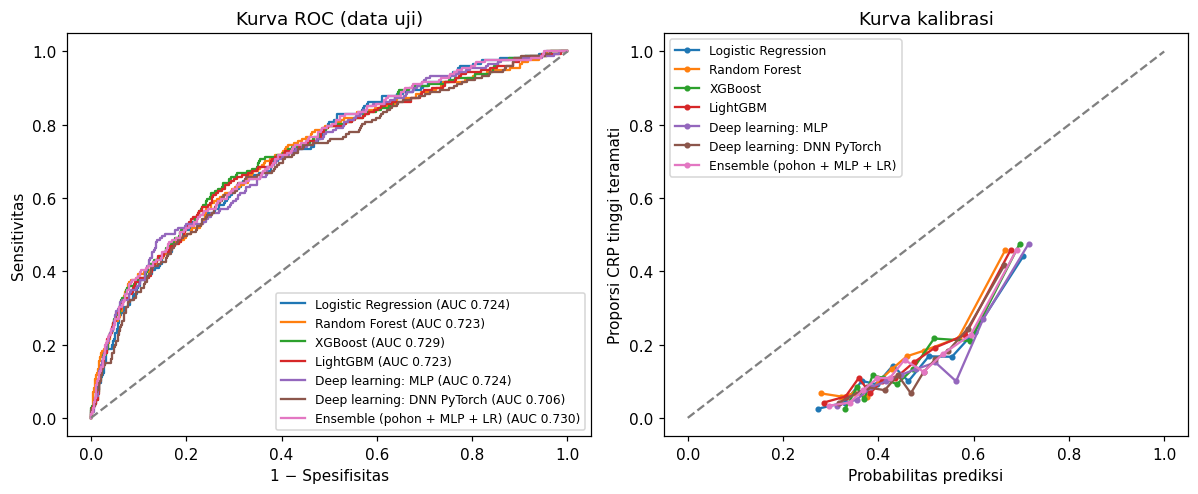

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for name, p in probs.items():
    f, t, _ = roc_curve(y_te, p); ax[0].plot(f, t, label=f'{name} (AUC {roc_auc_score(y_te, p):.3f})')
    fr, mp = calibration_curve(y_te, p, n_bins=10, strategy='quantile'); ax[1].plot(mp, fr, marker='o', ms=3, label=name)
ax[0].plot([0, 1], [0, 1], ls='--', c='grey'); ax[0].set(xlabel='1 − Spesifisitas', ylabel='Sensitivitas', title='Kurva ROC (data uji)')
ax[1].plot([0, 1], [0, 1], ls='--', c='grey'); ax[1].set(xlabel='Probabilitas prediksi', ylabel='Proporsi CRP tinggi teramati', title='Kurva kalibrasi')
ax[0].legend(fontsize=8, loc='lower right'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('gambar1_roc_kalibrasi.png', dpi=300); plt.show()

## 7. Gambar 2 — Variabel paling berpengaruh (SHAP; mode pratinjau: *permutation importance*)

Interpretasi memakai model pohon terbaik (`EXPLAIN`), karena SHAP untuk model pohon bersifat eksak dan standar dilaporkan.

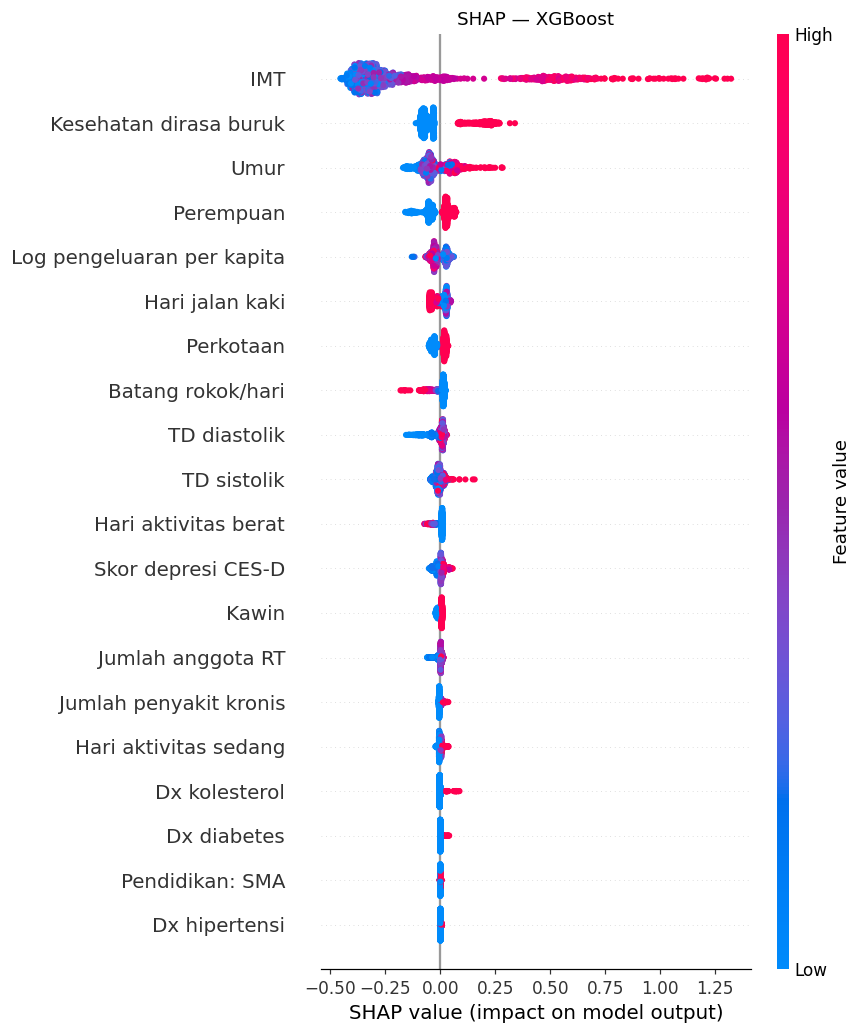

,mean |SHAP|
IMT,0.3474
Kesehatan dirasa buruk,0.0916
Umur,0.0610
Perempuan,0.0447
Log pengeluaran per kapita,0.0294
Hari jalan kaki,0.0266
Perkotaan,0.0257
Batang rokok/hari,0.0233
TD diastolik,0.0191
TD sistolik,0.0139


In [15]:
best = fitted[EXPLAIN]
Xt_te = pd.DataFrame(best.named_steps['p'].transform(X_te), columns=best.named_steps['p'].get_feature_names_out())
def nice(c):
    for k, v in LABEL.items():
        if c == k: return v
        if c.startswith(k + '_'):
            lv = c[len(k) + 1:].split('.')[0]
            m = {'educ': {'0': 'tdk sekolah', '1': 'SD', '2': 'SMP', '3': 'SMA', '4': 'PT'}, 'smoke_status': {'0': 'tdk pernah', '1': 'mantan', '2': 'aktif'}}
            return f"{v}: {m.get(k, {}).get(lv, lv)}"
    return c
Xt_te.columns = [nice(c) for c in Xt_te.columns]

if HAS_SHAP:
    import shap
    mdl = best.named_steps['m']
    explainer = shap.LinearExplainer(mdl, Xt_te) if EXPLAIN == 'Logistic Regression' else shap.TreeExplainer(mdl)
    sv = explainer.shap_values(Xt_te)
    sv = sv[1] if isinstance(sv, list) else (sv[:, :, 1] if np.ndim(sv) == 3 else sv)
    shap.summary_plot(sv, Xt_te, max_display=20, show=False); plt.title(f'SHAP — {EXPLAIN}'); plt.tight_layout()
    plt.savefig('gambar2_shap_summary.png', dpi=300, bbox_inches='tight'); plt.show()
    imp = pd.Series(np.abs(sv).mean(0), index=Xt_te.columns).sort_values(ascending=False)
    imp_label = 'mean |SHAP|'
else:
    pi = permutation_importance(best, X_te, y_te, scoring='roc_auc', n_repeats=20, random_state=SEED, n_jobs=-1)
    imp = pd.Series(pi.importances_mean, index=[LABEL[c] for c in FEATS]).sort_values(ascending=False)
    imp_label = 'Penurunan AUC jika variabel diacak'
    imp.head(15)[::-1].plot.barh(figsize=(7, 5.5), color='#4472C4'); plt.xlabel(imp_label)
    plt.title(f'Permutation importance — {EXPLAIN} (pratinjau)'); plt.tight_layout(); plt.savefig('gambar2_importance.png', dpi=300); plt.show()
peringkat = imp.round(4).rename(imp_label).to_frame().head(15)
peringkat

## 8. Gambar 3 — Arah pengaruh IMT, umur, dan pengeluaran per kapita

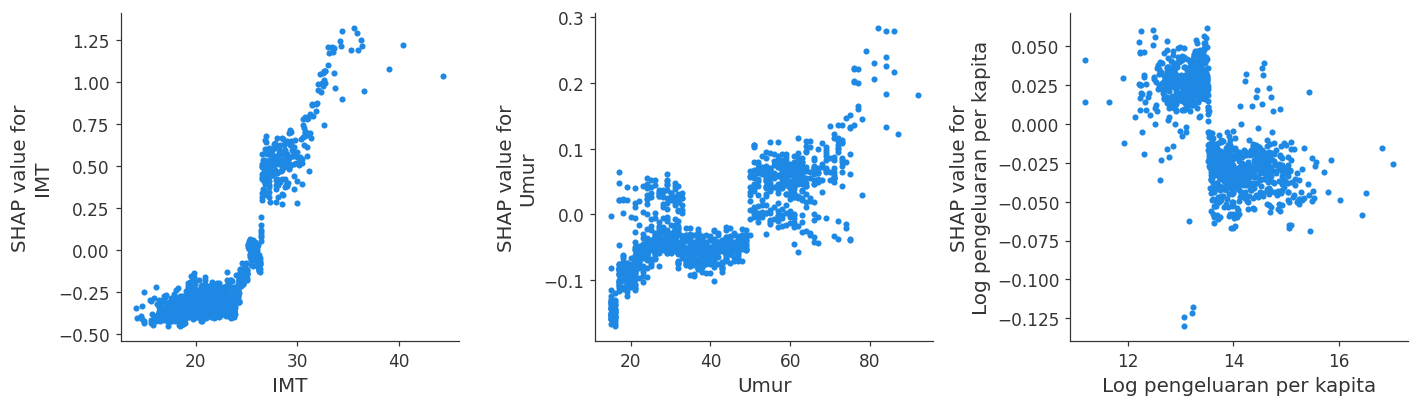

In [16]:
from sklearn.inspection import PartialDependenceDisplay
if HAS_SHAP:
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
    for a, f in zip(ax, ['IMT', 'Umur', 'Log pengeluaran per kapita']):
        shap.dependence_plot(f, sv, Xt_te, interaction_index=None, ax=a, show=False)
    plt.tight_layout(); plt.savefig('gambar3_shap_dependence.png', dpi=300); plt.show()
else:
    fig, ax = plt.subplots(figsize=(13, 3.8))
    PartialDependenceDisplay.from_estimator(best, X_te, ['bmi', 'age', 'lnpce'], kind='average', ax=ax)
    for a, t in zip(fig.axes[1:], ['IMT', 'Umur', 'Log pengeluaran per kapita']): a.set_xlabel(t)
    plt.suptitle('Partial dependence (pratinjau): probabilitas CRP tinggi', y=1.02); plt.tight_layout()
    plt.savefig('gambar3_partial_dependence.png', dpi=300, bbox_inches='tight'); plt.show()

## 9. Model per jenis kelamin — Tabel 3

Ini menjawab pertanyaan penelitian 3, termasuk apakah efek "protektif" merokok hilang setelah laki-laki dan perempuan dipisah.

In [17]:
from sklearn.base import clone
FEATS_S = [f for f in FEATS if f != 'female']
out = {}
for sx, lab in [(0, 'Laki-laki'), (1, 'Perempuan')]:
    tr, te = X_tr.female == sx, X_te.female == sx
    NUM_, BIN_ = NUM, [b for b in BIN if b != 'female']
    pre = ColumnTransformer([('num', SimpleImputer(strategy='median'), NUM_), ('bin', SimpleImputer(strategy='most_frequent'), BIN_),
                             ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')), ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CAT)])
    m = Pipeline([('p', pre), ('m', clone(fitted[EXPLAIN].named_steps['m']))]).fit(X_tr.loc[tr, FEATS_S], y_tr[tr.values])
    p = m.predict_proba(X_te.loc[te, FEATS_S])[:, 1]
    pi = permutation_importance(m, X_te.loc[te, FEATS_S], y_te[te.values], scoring='roc_auc', n_repeats=20, random_state=SEED, n_jobs=-1)
    s = pd.Series(pi.importances_mean, index=[LABEL[c] for c in FEATS_S]).sort_values(ascending=False)
    out[f'{lab} (AUC {roc_auc_score(y_te[te.values], p):.3f}, n uji={te.sum()})'] = [f'{k} ({v:.3f})' for k, v in s.head(10).items()]
tabel3 = pd.DataFrame(out, index=range(1, 11)); tabel3.index.name = 'Peringkat'
tabel3

,"Laki-laki (AUC 0.671, n uji=562)","Perempuan (AUC 0.702, n uji=634)"
Peringkat,,
1,IMT (0.071),IMT (0.179)
2,Kesehatan dirasa buruk (0.025),Kesehatan dirasa buruk (0.014)
3,TD diastolik (0.007),Perkotaan (0.004)
4,Janda/duda (0.004),Kawin (0.002)
5,Dx paru lain (0.003),Umur (0.001)
6,Jumlah anggota RT (0.002),Hari jalan kaki (0.001)
7,Hari jalan kaki (0.001),Jumlah penyakit kronis (0.001)
8,Skor depresi CES-D (0.001),Hari aktivitas berat (0.000)
9,Status merokok (0.001),Status merokok (0.000)


## 10. Analisis sensitivitas

In [18]:
sens = []
base = fitted[EXPLAIN]
def eval_auc(m, Xa, ya, Xb, yb, w=None):
    kw = {'m__sample_weight': w} if w is not None else {}
    m.fit(Xa, ya, **kw); p = m.predict_proba(Xb)[:, 1]; return roc_auc_score(yb, p)

# (a) bobot sampel DBS
w = df.loc[idx_tr, 'pwt14dbsxa'].fillna(df.pwt14dbsxa.median()).values
sens.append({'Analisis': 'Model utama', 'n latih': len(y_tr), 'AUC uji': tabel2.set_index('Model').loc[EXPLAIN, 'AUC-ROC']})
sens.append({'Analisis': 'Dengan bobot sampel DBS', 'n latih': len(y_tr), 'AUC uji': eval_auc(clone(base), X_tr, y_tr, X_te, y_te, w)})
# (b) SMOTE (hanya di data latih)
if HAS_IMB:
    from imblearn.pipeline import Pipeline as IPipe
    from imblearn.over_sampling import SMOTE
    est = clone(base.named_steps['m'])
    if hasattr(est, 'class_weight'): est.set_params(class_weight=None)
    if HAS_XGB and EXPLAIN == 'XGBoost': est.set_params(scale_pos_weight=1)
    sm = IPipe([('p', prep(EXPLAIN == 'Logistic Regression')), ('s', SMOTE(random_state=SEED)), ('m', est)])
    sens.append({'Analisis': 'SMOTE (pengganti class weight)', 'n latih': len(y_tr), 'AUC uji': eval_auc(sm, X_tr, y_tr, X_te, y_te)})
# (c) umur >=40 + lingkar pinggang
s40 = df.age >= 40
d40 = df[s40 & df.waist.notna()]
NUMw = NUM + ['waist']
pre_w = ColumnTransformer([('num', SimpleImputer(strategy='median'), NUMw), ('bin', SimpleImputer(strategy='most_frequent'), BIN),
                           ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')), ('o', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CAT)])
a_tr, a_te, b_tr, b_te = train_test_split(d40[FEATS + ['waist']], d40.crp_high.values, test_size=0.2, stratify=d40.crp_high, random_state=SEED)
for lab, cols, pre_ in [('Umur ≥40 tanpa lingkar pinggang', FEATS, prep(EXPLAIN == 'Logistic Regression')), ('Umur ≥40 + lingkar pinggang', FEATS + ['waist'], pre_w)]:
    m = Pipeline([('p', pre_), ('m', clone(base.named_steps['m']))])
    sens.append({'Analisis': lab, 'n latih': len(b_tr), 'AUC uji': eval_auc(m, a_tr[cols], b_tr, a_te[cols], b_te)})
tabel_sens = pd.DataFrame(sens).round(3)
tabel_sens

,Analisis,n latih,AUC uji
0,Model utama,4784,0.729
1,Dengan bobot sampel DBS,4784,0.728
2,SMOTE (pengganti class weight),4784,0.710
3,Umur ≥40 tanpa lingkar pinggang,2328,0.627
4,Umur ≥40 + lingkar pinggang,2328,0.634


## 11. Simpan semua hasil

In [19]:
with pd.ExcelWriter('hasil_model_crp.xlsx') as xw:
    tabel1.to_excel(xw, sheet_name='Tabel1_deskriptif', index=False)
    tabel2.to_excel(xw, sheet_name='Tabel2_kinerja', index=False)
    tabel_ambang.to_excel(xw, sheet_name='Ambang_sensitivitas', index=False)
    tabel_spes.to_excel(xw, sheet_name='Sens_pada_spes_tetap', index=False)
    tabel_selisih.to_excel(xw, sheet_name='Selisih_AUC_bootstrap', index=False)
    tabel_or.to_excel(xw, sheet_name='Regresi_logistik_OR', index=False)
    peringkat.to_excel(xw, sheet_name='Peringkat_variabel')
    tabel3.to_excel(xw, sheet_name='Tabel3_per_jenis_kelamin')
    tabel_sens.to_excel(xw, sheet_name='Sensitivitas', index=False)
print('Tersimpan: hasil_model_crp.xlsx + gambar*.png | MODE =', MODE)

Tersimpan: hasil_model_crp.xlsx + gambar*.png | MODE = FINAL


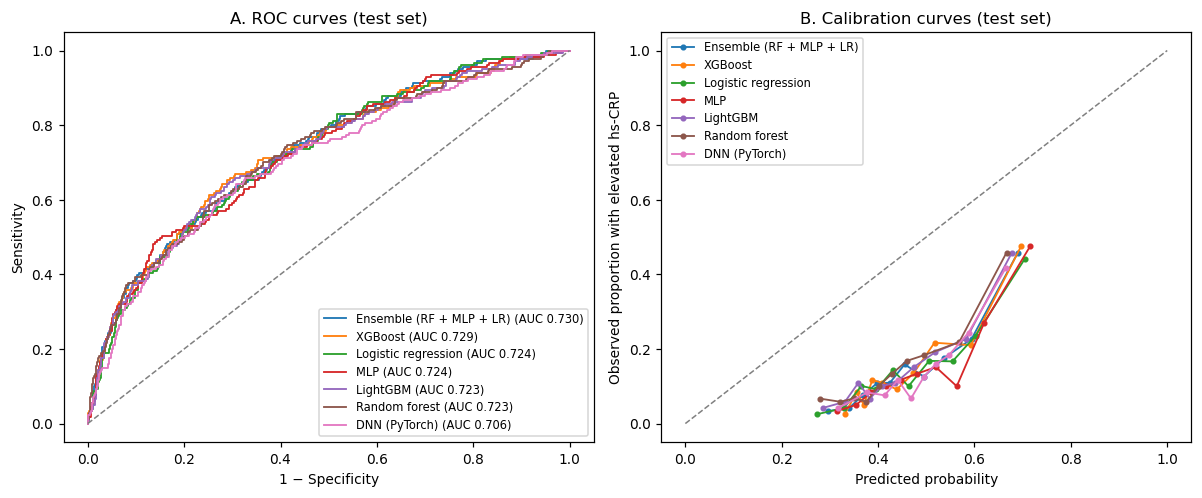

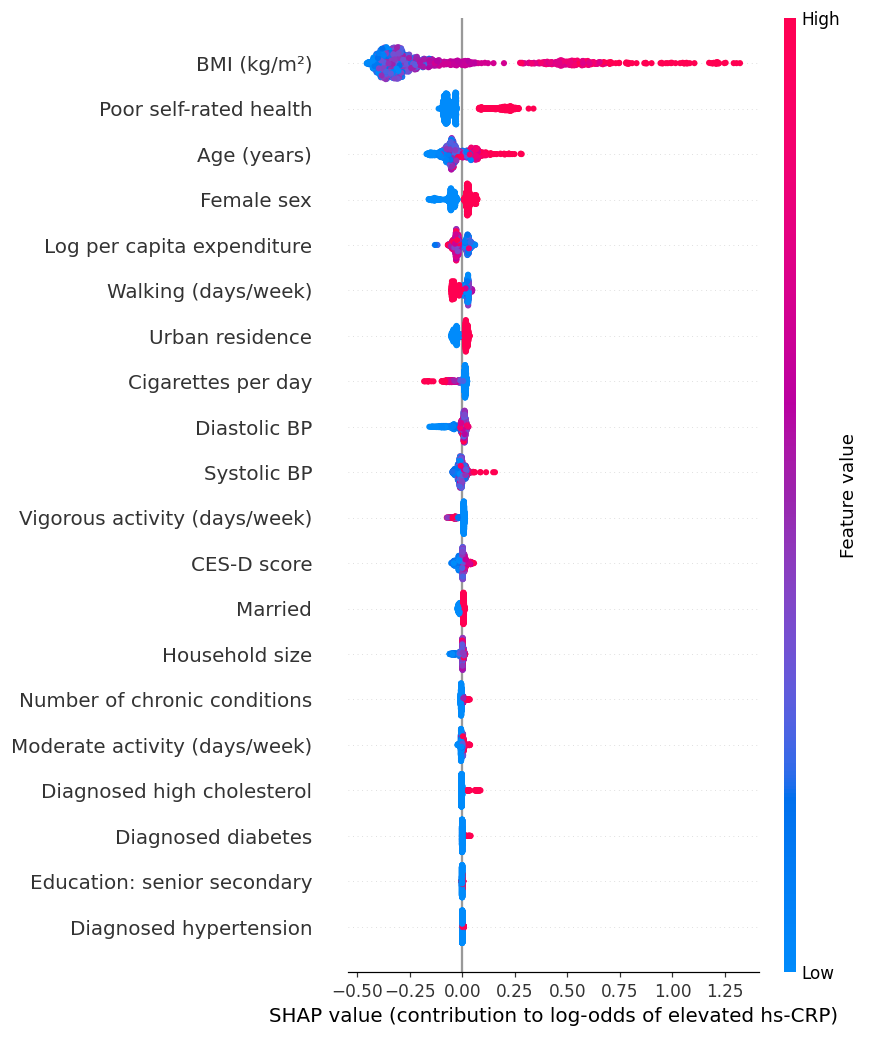

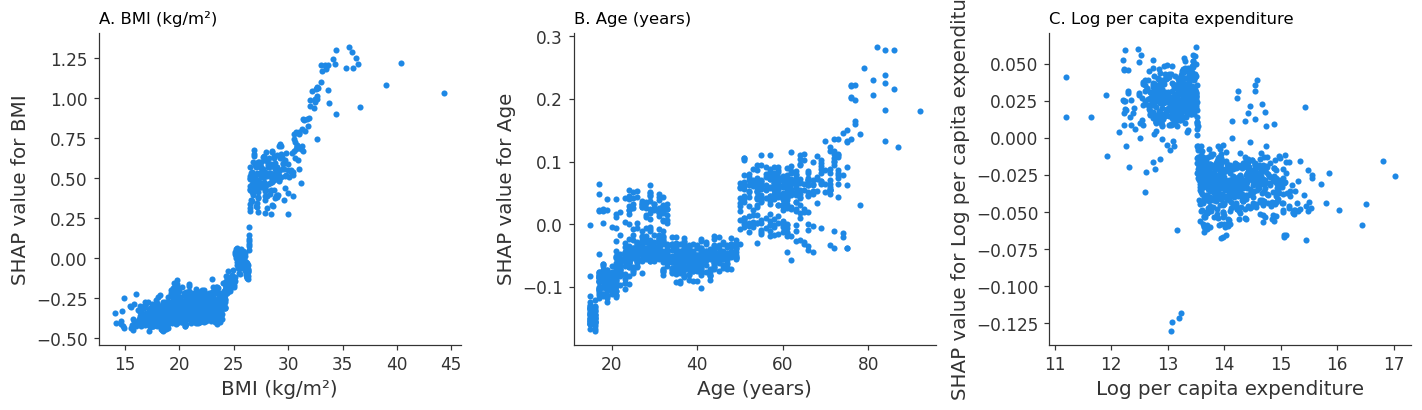

Saved: fig1_roc_calibration, fig2_shap_summary, fig3_shap_dependence (.png 300 dpi + .tiff 600 dpi)


In [20]:
# === FIGURES IN ENGLISH FOR THE JOURNAL (run after all other cells) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.calibration import calibration_curve

MODEL_EN = {'Ensemble (pohon + MLP + LR)': 'Ensemble (RF + MLP + LR)', 'XGBoost': 'XGBoost',
            'Logistic Regression': 'Logistic regression', 'Deep learning: MLP': 'MLP',
            'LightGBM': 'LightGBM', 'Random Forest': 'Random forest', 'Deep learning: DNN PyTorch': 'DNN (PyTorch)'}
FEAT_EN = {'age': 'Age (years)', 'lnpce': 'Log per capita expenditure', 'hhsize': 'Household size',
           'cig_day': 'Cigarettes per day', 'pa_vig_days': 'Vigorous activity (days/week)',
           'pa_mod_days': 'Moderate activity (days/week)', 'pa_walk_days': 'Walking (days/week)',
           'bmi': 'BMI (kg/m²)', 'sbp': 'Systolic BP', 'dbp': 'Diastolic BP', 'n_chronic': 'Number of chronic conditions',
           'cesd10': 'CES-D score', 'female': 'Female sex', 'married': 'Married', 'widowed': 'Widowed', 'urban': 'Urban residence',
           'dx_hypert': 'Diagnosed hypertension', 'dx_diab': 'Diagnosed diabetes', 'dx_heart': 'Diagnosed heart disease',
           'dx_stroke': 'Diagnosed stroke', 'dx_chol': 'Diagnosed high cholesterol', 'dx_asthma': 'Diagnosed asthma',
           'dx_lung': 'Diagnosed other lung disease', 'dx_arthritis': 'Diagnosed arthritis', 'dx_kidney': 'Diagnosed kidney disease',
           'dx_liver': 'Diagnosed liver disease', 'dx_digest': 'Diagnosed digestive disease', 'med_hypert': 'Antihypertensive use',
           'med_diab': 'Antidiabetic use', 'srh_poor': 'Poor self-rated health', 'educ': 'Education', 'smoke_status': 'Smoking'}
LEVEL_EN = {'educ': {'0': 'none', '1': 'primary', '2': 'junior secondary', '3': 'senior secondary', '4': 'tertiary'},
            'smoke_status': {'0': 'never', '1': 'former', '2': 'current'}}

def nice_en(c):
    if c in FEAT_EN: return FEAT_EN[c]
    for k in LEVEL_EN:
        if c.startswith(k + '_'):
            lv = c[len(k) + 1:].split('.')[0]
            return f"{FEAT_EN[k]}: {LEVEL_EN[k].get(lv, lv)}"
    return c

plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 9})
def save(fig, name):
    fig.savefig(name + '.png', dpi=300, bbox_inches='tight')
    fig.savefig(name + '.tiff', dpi=600, bbox_inches='tight', pil_kwargs={'compression': 'tiff_lzw'})

# Fig. 1 — ROC and calibration
order = sorted(probs, key=lambda k: -roc_auc_score(y_te, probs[k]))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for name in order:
    p = probs[name]
    f, t, _ = roc_curve(y_te, p)
    ax[0].plot(f, t, lw=1.2, label=f'{MODEL_EN.get(name, name)} (AUC {roc_auc_score(y_te, p):.3f})')
    fr, mp = calibration_curve(y_te, p, n_bins=10, strategy='quantile')
    ax[1].plot(mp, fr, marker='o', ms=3, lw=1.2, label=MODEL_EN.get(name, name))
for a in ax: a.plot([0, 1], [0, 1], ls='--', c='grey', lw=1)
ax[0].set(xlabel='1 − Specificity', ylabel='Sensitivity', title='A. ROC curves (test set)')
ax[1].set(xlabel='Predicted probability', ylabel='Observed proportion with elevated hs-CRP', title='B. Calibration curves (test set)')
ax[0].legend(fontsize=7.5, loc='lower right'); ax[1].legend(fontsize=7.5, loc='upper left')
plt.tight_layout(); save(fig, 'fig1_roc_calibration'); plt.show()

# Fig. 2 — SHAP summary (XGBoost)
import shap
Xen = pd.DataFrame(best.named_steps['p'].transform(X_te), columns=best.named_steps['p'].get_feature_names_out())
Xen.columns = [nice_en(c) for c in Xen.columns]
plt.figure()
shap.summary_plot(sv, Xen, max_display=20, show=False)
fig = plt.gcf(); fig.axes[0].set_xlabel('SHAP value (contribution to log-odds of elevated hs-CRP)')
plt.tight_layout(); save(fig, 'fig2_shap_summary'); plt.show()

# Fig. 3 — SHAP dependence for BMI, age and expenditure
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for a, f, tag in zip(ax, ['BMI (kg/m²)', 'Age (years)', 'Log per capita expenditure'], 'ABC'):
    shap.dependence_plot(f, sv, Xen, interaction_index=None, ax=a, show=False)
    a.set_ylabel(f'SHAP value for {f.split(" (")[0]}'); a.set_title(f'{tag}. {f}', loc='left')
plt.tight_layout(); save(fig, 'fig3_shap_dependence'); plt.show()
print('Saved: fig1_roc_calibration, fig2_shap_summary, fig3_shap_dependence (.png 300 dpi + .tiff 600 dpi)')

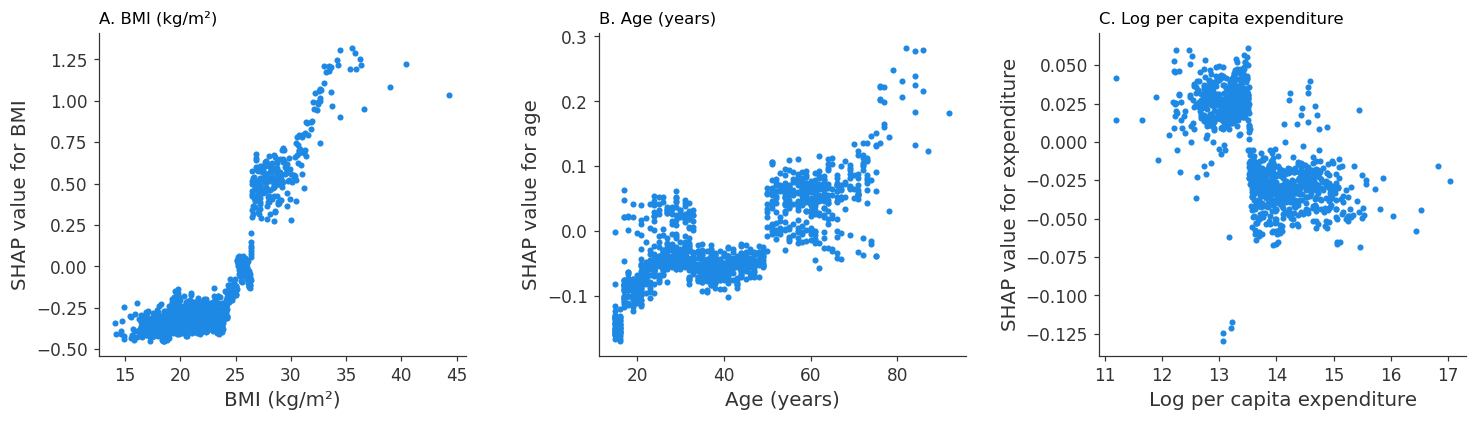

Saved: fig3_shap_dependence (.png + .tiff)


In [21]:
# Fig. 3 — perbaikan label sumbu-Y yang terpotong
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.9))
panels = [('BMI (kg/m²)', 'SHAP value for BMI'),
          ('Age (years)', 'SHAP value for age'),
          ('Log per capita expenditure', 'SHAP value for expenditure')]
for a, (f, ylab), tag in zip(ax, panels, 'ABC'):
    shap.dependence_plot(f, sv, Xen, interaction_index=None, ax=a, show=False)
    a.set_ylabel(ylab); a.set_title(f'{tag}. {f}', loc='left')
plt.tight_layout(w_pad=2.5); save(fig, 'fig3_shap_dependence'); plt.show()
print('Saved: fig3_shap_dependence (.png + .tiff)')